In [3]:
# Import libraries               # Same
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Reload the original dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Convert date column
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# Convert skill strings into real Python lists
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

# Now filter to Data Engineeer jobs
df = df[df['job_title_short'] == 'Data Engineer']

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Keep only U.S. Data Engineer job postings
# & means BOTH conditions must be True
# .copy() creates a separate DataFrame so we don't modify the original df
df_DE_US = df[
    (df['job_title_short'] == 'Data Engineer') &
    (df['job_country'] == 'United States')
].copy()

# Remove rows where salary_year_avg is missing (NaN)
# Boxplots can't be created with missing salary values
df_DE_US = df_DE_US.dropna(subset=['salary_year_avg'])

# Randomly display 10 salary values
# .sample(10) is useful for quickly inspecting the data
df_DE_US['salary_year_avg'].sample(10)

176257    140000.0000
377062    137320.3125
12124     175000.0000
118313    115000.0000
246420    125000.0000
626328    150000.0000
533807    110000.0000
119490    172500.0000
72858     120000.0000
352151    194500.0000
Name: salary_year_avg, dtype: float64

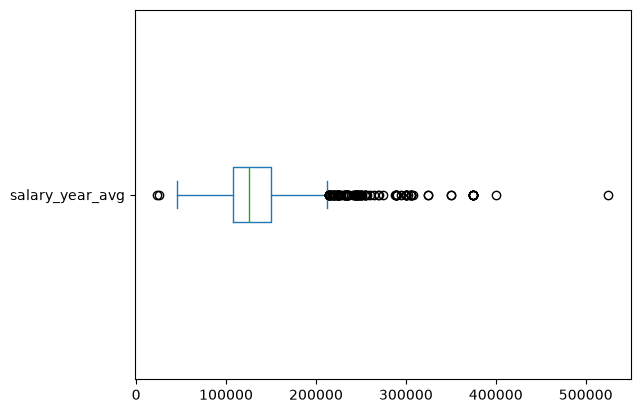

In [5]:
# Create a boxplot of yearly salaries for U.S. Data Engineers
df_DE_US['salary_year_avg'].plot(
    kind='box',      # Draw a boxplot
    vert=False       # False = horizontal boxplot (True = vertical)
)

# Display the chart
plt.show()

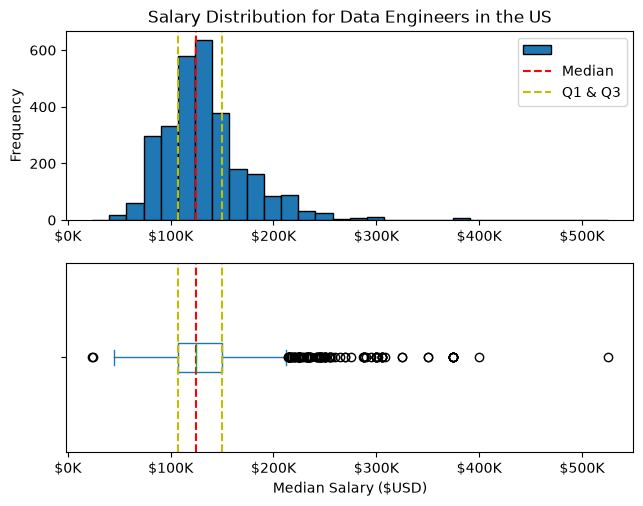

In [6]:
# Create a figure with 2 plots stacked vertically (2 rows, 1 column)
fig, ax = plt.subplots(2, 1)

# Add a little vertical spacing so the plots don't overlap
fig.tight_layout(h_pad=1)

# ==========================
# Top plot: Histogram
# ==========================

# Plot the salary distribution
df_DE_US['salary_year_avg'].plot(
    kind='hist',
    ax=ax[0],           # Draw on the first subplot
    bins=30,            # Split salaries into 30 groups
    edgecolor='black'   # Black borders around each bar
)

# Add chart title
ax[0].set_title('Salary Distribution for Data Engineers in the US')

# Remove x-axis label (we'll label it below)
ax[0].set_xlabel('')

# Label the y-axis
ax[0].set_ylabel('Frequency')

# Format salary axis like $100K instead of 100000
ax[0].xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: '${:g}K'.format(x / 1000)
    )
)

# Add summary statistic lines
# Red = Median salary
ax[0].axvline(
    df_DE_US['salary_year_avg'].median(),
    color='r',
    linestyle='--'
)

# Yellow = First Quartile (25%)
ax[0].axvline(
    df_DE_US['salary_year_avg'].quantile(0.25),
    color='y',
    linestyle='--'
)

# Yellow = Third Quartile (75%)
ax[0].axvline(
    df_DE_US['salary_year_avg'].quantile(0.75),
    color='y',
    linestyle='--'
)

# Add legend
ax[0].legend(['', 'Median', 'Q1 & Q3'])

# ==========================
# Bottom plot: Boxplot
# ==========================

# Plot the same salary data as a boxplot
df_DE_US['salary_year_avg'].plot(
    kind='box',
    ax=ax[1],       # Draw on second subplot
    vert=False      # Horizontal boxplot
)

# Remove y-axis tick labels
ax[1].set_yticklabels([''])

# Label x-axis
ax[1].set_xlabel('Median Salary ($USD)')

# Remove y-axis label
ax[1].set_ylabel('')

# Format salary axis like $100K
ax[1].xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: '${:g}K'.format(x / 1000)
    )
)

# Draw the same summary lines
ax[1].axvline(
    df_DE_US['salary_year_avg'].median(),
    color='r',
    linestyle='--'
)

ax[1].axvline(
    df_DE_US['salary_year_avg'].quantile(0.25),
    color='y',
    linestyle='--'
)

ax[1].axvline(
    df_DE_US['salary_year_avg'].quantile(0.75),
    color='y',
    linestyle='--'
)

# Display both charts
plt.show()

In [7]:
# -----------------------------------------
# Reload the full dataset (don't filter yet)
# -----------------------------------------

import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Load dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Convert date column
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

# Convert string representation of lists into actual Python lists
df["job_skills"] = df["job_skills"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

# Keep only U.S. jobs
df_US = df[df["job_country"] == "United States"].copy()

# Remove rows without salary information
df_US = df_US.dropna(subset=["salary_year_avg"])

In [8]:
# Job titles we want to compare
job_titles = [
    'Data Engineer',
    'Data Scientist',
    'Data Analyst'
]

# Keep only these job titles in the U.S.
df_US = df[
    (df['job_title_short'].isin(job_titles)) &
    (df['job_country'] == 'United States')
].copy()

# Remove rows with missing salaries
df_US = df_US.dropna(subset=['salary_year_avg'])

/var/folders/g8/653mbdtn65n85h__s3gx0z3r0000gn/T/ipykernel_96346/3241393185.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


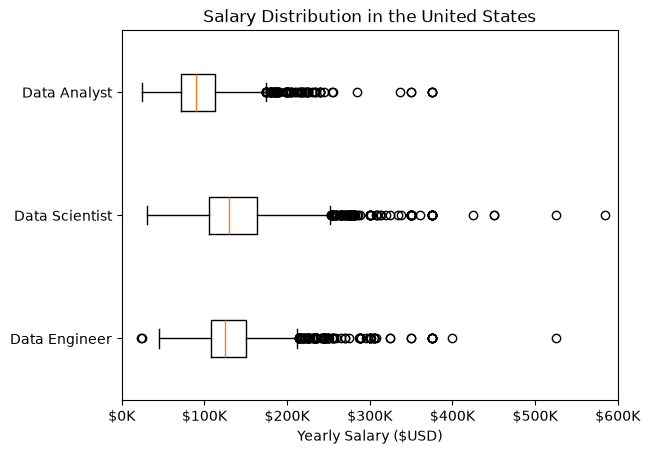

In [9]:
# Create a list of salary Series, one for each job title
job_list = [
    df_US[df_US['job_title_short'] == job_title]['salary_year_avg']
    for job_title in job_titles
]

# Create one horizontal boxplot for each job title
plt.boxplot(
    job_list,
    tick_labels=job_titles,   # Labels for each boxplot
    vert=False                # Horizontal boxplots
)

# Add chart title
plt.title('Salary Distribution in the United States')

# Label x-axis
plt.xlabel('Yearly Salary ($USD)')

# Get the current axes so we can format the salary numbers
ax = plt.gca()

# Format salary values like 100000 -> $100K
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f'${int(x / 1000)}K'
    )
)

# Limit visible salary range
plt.xlim(0, 600000)

# Display chart
plt.show()

# Comparing Salary Distributions Across Data Roles

## Objective
Compare the yearly salary distributions of three major data careers in the United States:

- Data Analyst
- Data Scientist
- Data Engineer

A boxplot is useful because it summarizes the distribution of salaries while also highlighting unusually high salaries (outliers).

---

## How to Read the Boxplot

Each horizontal box represents one job title.

- **Orange line** → Median (middle salary)
- **Box** → Middle 50% of salaries (25th to 75th percentile)
- **Whiskers** → Typical salary range
- **Dots outside the whiskers** → Outliers (very high or very low salaries)

---

## Observations

- **Data Scientists** generally have the highest salary distribution and the highest extreme salaries.
- **Data Engineers** also earn high salaries, with a median slightly above Data Analysts.
- **Data Analysts** have the lowest median salary among the three roles.
- All three careers contain high-paying outlier positions, showing that specialized experience and seniority can significantly increase compensation.

---

## Key Takeaway

Although there is overlap between the salary ranges, the overall trend shows:

**Data Scientist ≥ Data Engineer > Data Analyst**

This visualization makes it easier to compare the spread, consistency, and earning potential of different careers rather than looking only at average salaries.